## Step 1: Business Problem Understandind

- **What is the relationship between each advertising channel (TV,Radio, Newspaper) and sales?**

- Previously, we explored is there a relationship between total advertising spend and sales? as well as predicting the total sales for some values of total spend.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib  inline

import seaborn as sns

## Step 2: Data Collection

In [25]:
df = pd.read_csv('Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230100,37800,69200,22100
1,44500,39300,45100,10400
2,17200,45900,69300,9300
3,151500,41300,58500,18500
4,180800,10800,58400,12900


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   TV         200 non-null    int64
 1   radio      200 non-null    int64
 2   newspaper  200 non-null    int64
 3   sales      200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [27]:
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

## Step 3.1: Exploratory Data Analysis (EDA)

On the basis of this data, how should you spend advertising money in the future? These general questions might lead you to more specific questions:

1. Is there a relationship between ads and sales?
2. How strong is that relationship?
3. Which ad types contribute to sales?
4. What is the effect of each ad type of sales?
5. Given ad spending, can sales be predicted?

In [28]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147042.500000,23264.000000,30554.000000,14022.500000
std,85854.236315,14846.809176,21778.620839,5217.456566
min,700.000000,0.000000,300.000000,1600.000000
25%,74375.000000,9975.000000,12750.000000,10375.000000
50%,149750.000000,22900.000000,25750.000000,12900.000000
75%,218825.000000,36525.000000,45100.000000,17400.000000
max,296400.000000,49600.000000,114000.000000,27000.000000


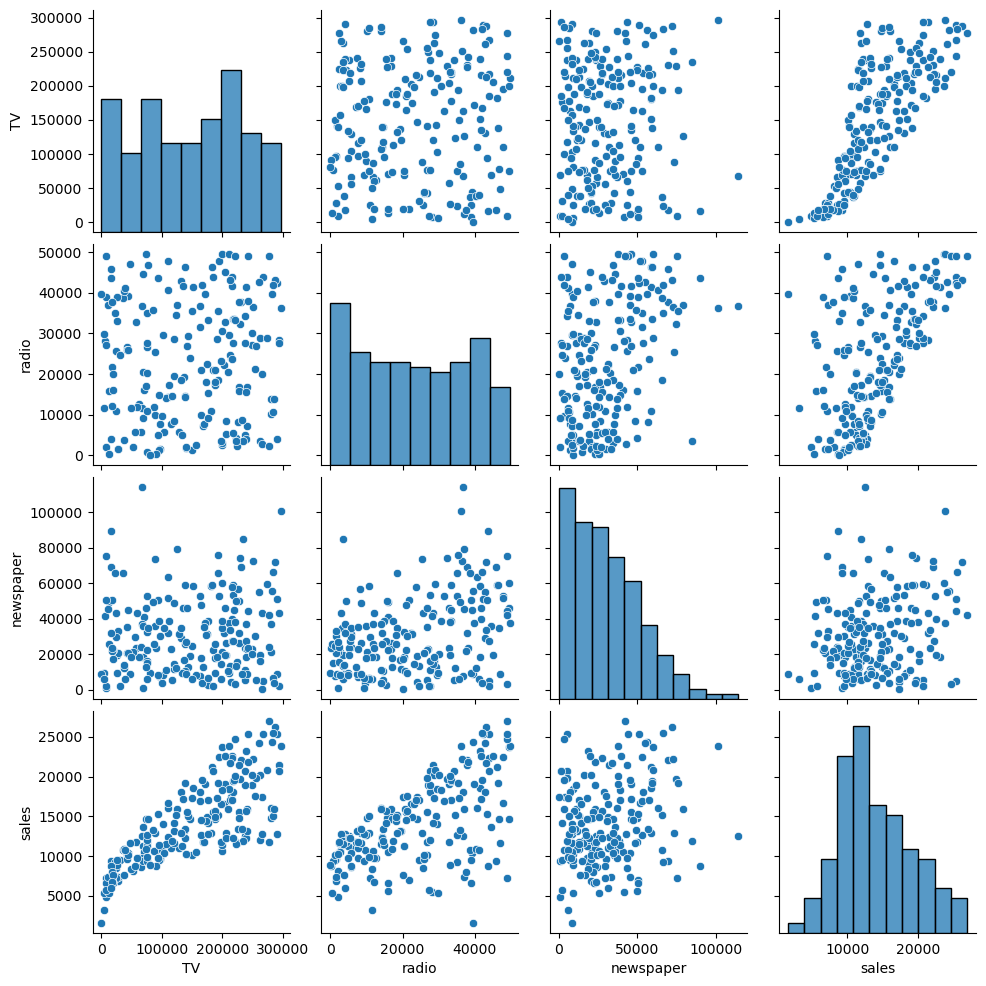

In [29]:
sns.pairplot(df)
plt.show()

**by observing the scatter plot, we made an assumption of the relation between y and (x1+x2+x3) is linear**

In [30]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


- The relation between y and x should be high.. The higher  the value the stronger the correlation
- The relation between any two independent variables should be low


**If the correlation between any 2 independent variables is strong, then it is called a colinearity problem**

## Step 3.2: Data Cleaning
## Step 3.3: Data Wrangling
## Step 3.4: Train- test split

In [31]:
# x = df[['TV','radio','newspaper']]
# y = df['sales']

In [32]:
X =df.drop(columns='sales')
y = df['sales']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


## Step 4: Modelling

**Multiple Linear Regression** - Linear regression include multiple input features. This is done by least squares method

y = B0 + B1x1 + B2x2 + ........+ BnXn

Each x represents a diffent feature, and each feature has its own coefficient.

- **In this case:**

y = B0 + B1 x TV + B2 x Radio + B3 x Newspaper



In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
model.intercept_

np.float64(2708.949092515906)

In [36]:
model.coef_

array([0.04405928, 0.1992875 , 0.00688245])

## Prediction

In [37]:
train_prediction = model.predict(X_train)


In [38]:
test_prediction = model.predict(X_test)

## Step 5: Evaluation Metrics

In [39]:
from sklearn.metrics import mean_squared_error
test_RMSE = np.sqrt(mean_squared_error(y_test, test_prediction))
train_RMSE = np.sqrt(mean_squared_error(y_train, train_prediction))
print(train_RMSE, test_RMSE)

1574.5968305905444 1948.5372043446382


In [40]:
model.score(X_train, y_train)

0.9055159502227753

In [41]:
model.score(X_test, y_test)

0.8609466508230368

## Checklist

- 1. Check whether model has overfitting or underfitting problem
- 2. Is Test Accuracy = Cross validation Score
- 3. Check Assumptions (if it is Linear Regression)
- 4. Check model meets the business problem requirements
- 5. Finally, save the model and share to the deployement team


#### 1. Is model has underfitting or underfitting problem?
**Answer: It's a good model.**

#### 2. Is Test Accuracy = Cross validation Score

In [42]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv = 5)
print(scores)
scores.mean()

[0.87865198 0.91763212 0.92933032 0.81443904 0.89547829]


np.float64(0.8871063495438435)

#### **Check for Assumptions**

**1. Linearity of Errors**

In [43]:
test_res = y_test - test_prediction

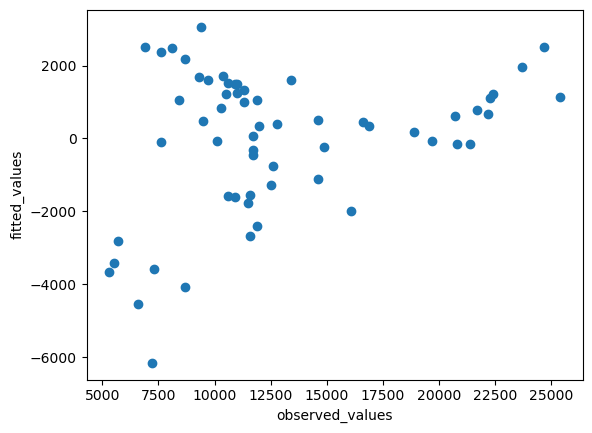

In [44]:
plt.scatter(y_test, test_res)
plt.xlabel('observed_values')
plt.ylabel('fitted_values')
plt.show()

**2. Nomality of Errors**

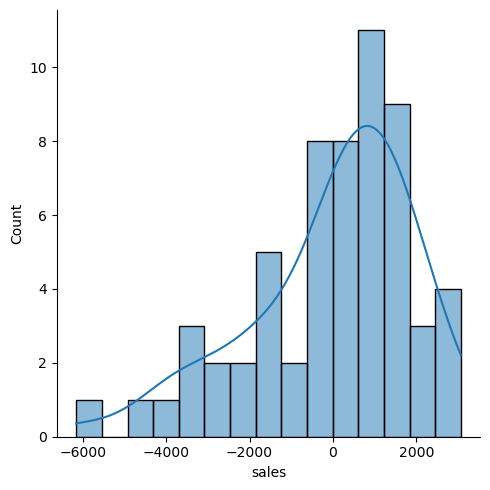

In [45]:
sns.displot(test_res, bins = 15, kde= True)
plt.show()

**3. Equal Variance of Errors (Homoscadesicity)**

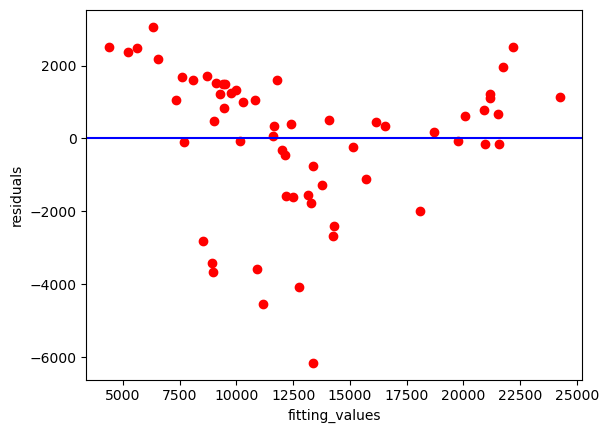

In [46]:
plt.scatter(test_prediction, test_res, c = 'r')
plt.axhline(y = 0, color = 'blue')
plt.xlabel('fitting_values')
plt.ylabel('residuals')
plt.show()

**4. Variables Significance**

**Hypothesis Testing for variables**

   - **null hypothesis:** There  is no relationship between  input variables and output variable (and thus B1 equals zero)

   - **alternative hypothesis:** There is a relationship between variable and output (and thus B1 is not equal to zero)

In [49]:
import statsmodels.formula.api as smf
model1 = smf.ols("y~X", data = df).fit()
model1.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           1.58e-96
Time:                        14:06:26   Log-Likelihood:                -1767.7
No. Observations:                 200   AIC:                             3543.
Df Residuals:                     196   BIC:                             3557.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2938.8894    311.908      9.422      0.000    2323.762    3554.016
X[0]           0.0458      0.001     32.809      0.000       0.043       0.049
X[1]           0.1885      0.009     21.893      0.000       0.172       0.206
X[2]          -0.0010      0.006     -0.177      0.860      -0.013       0.011
==============================================================================
Omnibus:                       60.414   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.241
Skew:                          -1.327   Prob(JB):                     1.44e-33
Kurtosis:                       6.332   Cond. No.                     4.54e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.54e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Checking whether data has any influential values by using influence index plots**

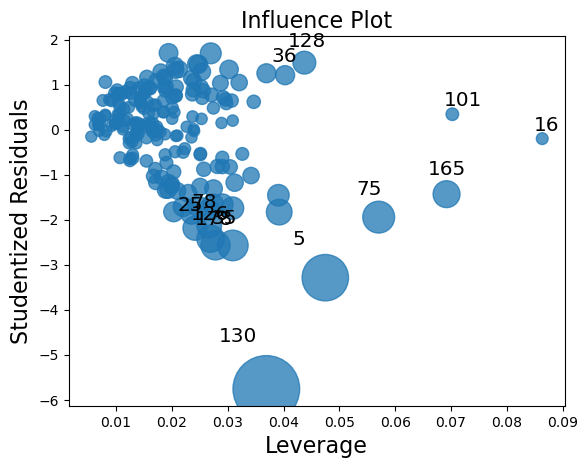

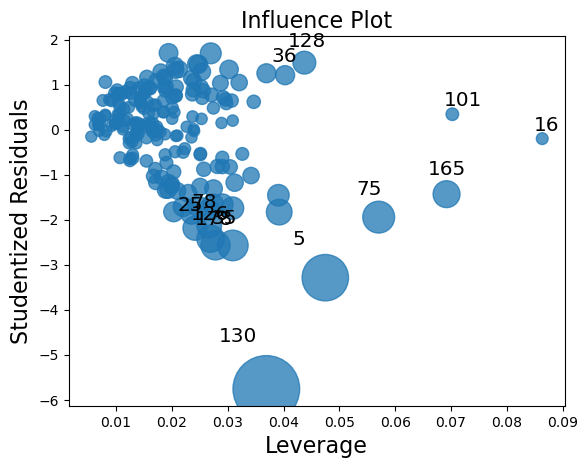

In [50]:
import statsmodels.api as sm
sm.graphics.influence_plot(model1)


In [51]:
df.iloc[130]

TV             700
radio        39600
newspaper     8700
sales         1600
Name: 130, dtype: int64

In [52]:
df_new = df.drop(df.index[[130]], axis = 0)
df_new

,TV,radio,newspaper,sales
0,230100,37800,69200,22100
1,44500,39300,45100,10400
2,17200,45900,69300,9300
3,151500,41300,58500,18500
4,180800,10800,58400,12900
...,...,...,...,...
195,38200,3700,13800,7600
196,94200,4900,8100,9700
197,177000,9300,6400,12800
198,283600,42000,66200,25500


- index 130 is showing high influence so we can exclude that entire row
- Studentized Residuals = Residual/standard deviation of residuals

In [53]:
df_new = df.drop(df.index[[130]], axis = 0)
df_new

,TV,radio,newspaper,sales
0,230100,37800,69200,22100
1,44500,39300,45100,10400
2,17200,45900,69300,9300
3,151500,41300,58500,18500
4,180800,10800,58400,12900
...,...,...,...,...
195,38200,3700,13800,7600
196,94200,4900,8100,9700
197,177000,9300,6400,12800
198,283600,42000,66200,25500


In [54]:
lm = smf.ols(formula='sales ~ TV + radio + newspaper', data = df_new).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     653.7
Date:                Wed, 23 Sep 2026   Prob (F-statistic):          1.88e-101
Time:                        14:11:41   Log-Likelihood:                -1743.8
No. Observations:                 199   AIC:                             3496.
Df Residuals:                     195   BIC:                             3509.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3093.0655    290.332     10.654      0.000    2520.471    3665.660
TV             0.0448      0.001     34.425      0.000       0.042       0.047
radio          0.1939      0.008     24.130      0.000       0.178       0.210
newspaper     -0.0043      0.005     -0.777      0.438      -0.015       0.007
==============================================================================
Omnibus:                       21.217   Durbin-Watson:                   2.157
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               24.630
Skew:                          -0.835   Prob(JB):                     4.48e-06
Kurtosis:                       3.423   Cond. No.                     4.56e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.56e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Variance Inflation (VIF)**

- VIF measures the ratio between the variance for a given regression coefficient with only that variable in the model versus the variance for a given regression coefficient with all variables in the model.

In [55]:
rsq_TV = smf.ols('TV~radio+newspaper', data=df).fit()
rsq_TV.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     TV   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.4542
Date:                Wed, 23 Sep 2026   Prob (F-statistic):              0.636
Time:                        14:14:26   Log-Likelihood:                -2554.9
No. Observations:                 200   AIC:                             5116.
Df Residuals:                     197   BIC:                             5126.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.366e+05   1.26e+04     10.826      0.000    1.12e+05    1.61e+05
radio          0.2298      0.440      0.523      0.602      -0.637       1.097
newspaper      0.1679      0.300      0.560      0.576      -0.423       0.759
==============================================================================
Omnibus:                       93.855   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               12.314
Skew:                          -0.089   Prob(JB):                      0.00212
Kurtosis:                       1.798   Cond. No.                     9.19e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.19e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [56]:
# calcuating VIF's values of independent variables

rsq_TV = smf.ols('TV~radio+newspaper', data = df).fit().rsquared
vif_TV = 1/(1-rsq_TV)

rsq_radio = smf.ols('radio~TV + newspaper', data = df).fit().rsquared
vif_radio = 1/(1-rsq_radio)

rsq_newspaper = smf.ols('newspaper~radio+TV', data = df).fit().rsquared
vif_newspaper = 1 / (1-rsq_newspaper)

In [57]:
# Storing vif values in a data frame

d1 = {

    'Variables':['TV','radio','newspaper'],
    'VIF':[vif_TV,vif_radio,vif_newspaper]
}

Vif_frame = pd.DataFrame(d1)
Vif_frame

,Variables,VIF
0,TV,1.004611
1,radio,1.144952
2,newspaper,1.145187


- If VIF > 4, for any independent variable, then drop the particular variable
- if the VIF of model> 4(threshold value = 4).. then there exists a problem and reinvestigate the problem




**Added variable plot (AV plot)**

- partial differention insted of normal differentiation

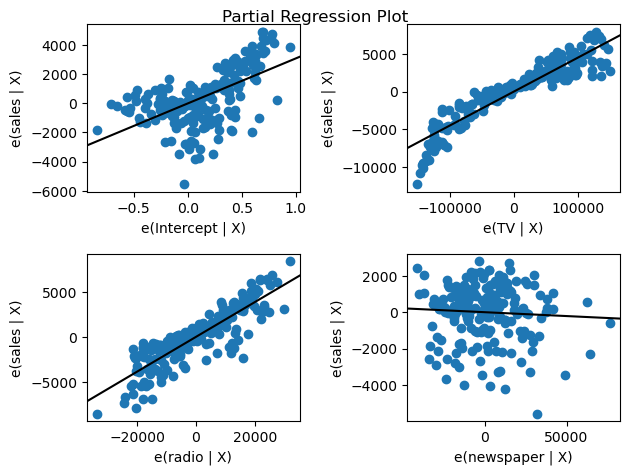

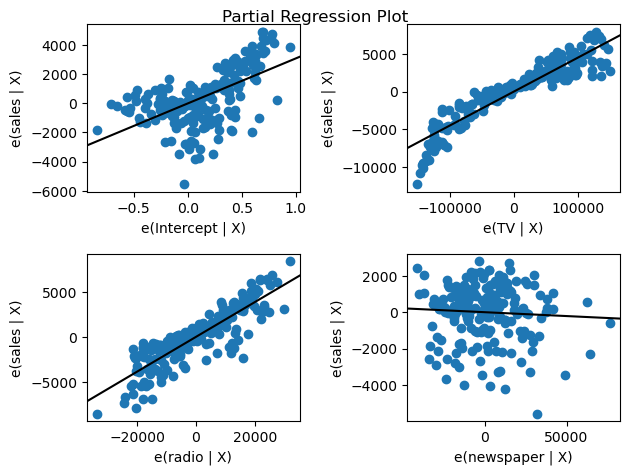

In [58]:
sm.graphics.plot_partregress_grid(lm)

- added variable plot is not showing any significance for newspaper

### **Final model including TV and Radio only**

In [59]:
final_model = smf.ols(formula='sales ~ TV + radio', data = df).fit()
final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           4.83e-98
Time:                        14:24:41   Log-Likelihood:                -1767.7
No. Observations:                 200   AIC:                             3541.
Df Residuals:                     197   BIC:                             3551.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2921.0999    294.490      9.919      0.000    2340.343    3501.857
TV             0.0458      0.001     32.909      0.000       0.043       0.048
radio          0.1880      0.008     23.382      0.000       0.172       0.204
==============================================================================
Omnibus:                       60.022   Durbin-Watson:                   2.081
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              148.679
Skew:                          -1.323   Prob(JB):                     5.19e-33
Kurtosis:                       6.292   Cond. No.                     4.25e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.25e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""